# Sampler Performance Test on NS1024 Checkpoints

Compare gradient statistics across different INR samplers (`random`, `NMT`, `2d_grid_linear`, `2d_grid_adaptive`, original) evaluated on the same set of checkpoints from a single training run.

In [2]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

In [3]:
%load_ext autoreload
%autoreload 2

## 1. Setup & Imports

In [4]:
from __future__ import annotations

import sys
import re
from pathlib import Path

# Add repo root to sys.path so local modules resolve correctly
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import copy
import random

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from torch_geometric.data import Data

# Local utilities from this repo
from gradient_test import (
    compute_sampled_gradients,
    _load_checkpoint,
    _build_graph,
    _apply_sampler_overrides,
    _weighted_mse,
    _call_sampler,
    _set_all_seeds,
    _flatten_gradients,
)
from train_utility_sampling.SamplerWrapper import create_inr_sampler
from utils.load_inr import create_inr_instance

print("Imports OK — repo root:", REPO_ROOT)

Imports OK — repo root: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE


## 2. Define Checkpoint Path & Device

In [5]:
CHECKPOINT_DIR = Path(
    "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/checkpoints/"
    "2026-04-18-20-53-04NS1024_single_random_re_10000_sampling_2e-3_lr_1e-4_depth_6_t100"
)

assert CHECKPOINT_DIR.is_dir(), f"Checkpoint dir not found: {CHECKPOINT_DIR}"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")

# Collect all numeric step checkpoints and sort them
NUMERIC_RE = re.compile(r"^(\d+)\.pt$")
checkpoint_steps = sorted(
    [(int(m.group(1)), p) for p in CHECKPOINT_DIR.glob("*.pt") if (m := NUMERIC_RE.match(p.name))],
    key=lambda x: x[0],
)
step_list = [s for s, _ in checkpoint_steps]
path_list = [p for _, p in checkpoint_steps]

print(f"\nFound {len(checkpoint_steps)} checkpoints: steps {step_list[:5]} ... {step_list[-3:]}")

Device : cuda
GPU    : NVIDIA A100-PCIE-40GB

Found 31 checkpoints: steps [0, 100, 200, 300, 400] ... [3700, 3900, 4000]


## 3. Define Sampler Configurations

Each entry maps a human-readable sampler name to a `sampler_overrides` dict passed to `compute_sampled_gradients()`.
`None` overrides preserves the original checkpoint sampler.

In [6]:
SAMPLER_CONFIGS: dict[str, dict | None] = {
    # Preserve the checkpoint's original sampler (random, rate 2e-3)
    "original (random 2e-3)": None,
    # Baseline: uniform random at a lower rate
    "random 4e-3": {"type": "random", "rate": 0.004},
    # NMT: error-guided top-k selection
    "NMT 2e-3": {"type": "NMT", "rate": 0.002},
    # Linear grid partitioning (cell-based baseline)
    "2d_grid_linear": {"type": "2d_grid_linear", "rate": 0.002},
    # Adaptive sampling driven by local loss variance
    "2d_grid_adaptive (loss)": {
        "type": "2d_grid_adaptive",
        "rate": 0.002,
        "adaptive_mode": "loss",
        "adaptive_iterations": 8,
        "adaptive_equal_cell_topk": True,
        "adaptive_equal_cell_topk_weight_mode": "area_over_count",
    },
}

# Number of independent sampling draws per checkpoint for each sampler
N_REPEATS = 5
SEED = 24

print("Sampler configurations:")
for name, cfg in SAMPLER_CONFIGS.items():
    print(f"  {name!r:40s} → {cfg}")

Sampler configurations:
  'original (random 2e-3)'                 → None
  'random 4e-3'                            → {'type': 'random', 'rate': 0.004}
  'NMT 2e-3'                               → {'type': 'NMT', 'rate': 0.002}
  '2d_grid_linear'                         → {'type': '2d_grid_linear', 'rate': 0.002}
  '2d_grid_adaptive (loss)'                → {'type': '2d_grid_adaptive', 'rate': 0.002, 'adaptive_mode': 'loss', 'adaptive_iterations': 8, 'adaptive_equal_cell_topk': True, 'adaptive_equal_cell_topk_weight_mode': 'area_over_count'}


## 4. Run Gradient Computation for All Samplers

Iterate over every checkpoint step and every sampler configuration. For each (step, sampler) pair
we call `compute_sampled_gradients()` with `N_REPEATS` repeated draws and store all gradient
vectors for downstream analysis.

In [7]:
import pickle

SAVE_DIR = CHECKPOINT_DIR.parent
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1) Raw gradient tensors: results[sampler_name][step] = list[torch.Tensor]
#    Serialise with pickle (tensors are on CPU already after compute_sampled_gradients)
raw_results_path = SAVE_DIR / "sampler_gradient_results.pkl"

In [8]:
# this cell generate data
rerun = False

import time

# results[sampler_name][step] = list of gradient tensors (one per repeat)
results: dict[str, dict[int, list[torch.Tensor]]] = {name: {} for name in SAMPLER_CONFIGS}
ITER = 10
if rerun:
    for step_idx, (step, ckpt_path) in enumerate(checkpoint_steps):
        print(f"\n[{step_idx+1}/{len(checkpoint_steps)}] Step {step} — {ckpt_path.name}")
        for sampler_name, overrides in SAMPLER_CONFIGS.items():
            t0 = time.perf_counter()
            try:
                grads = compute_sampled_gradients(
                    checkpoint_path=ckpt_path,
                    sampler_overrides=overrides,
                    n_repeats=N_REPEATS,
                    seed=SEED,
                    device=DEVICE,
                )
                results[sampler_name][step] = grads
                elapsed = time.perf_counter() - t0
                norms = [g.norm().item() for g in grads]
                print(f"  {sampler_name!r:40s}  norms={[f'{n:.4f}' for n in norms]}  ({elapsed:.1f}s)")
            except Exception as exc:
                print(f"  {sampler_name!r:40s}  ERROR: {exc}")
                results[sampler_name][step] = []

    print("\nDone — all checkpoints processed.")


    # ── Save all generated results ────────────────────────────────────────────────

    with open(raw_results_path, "wb") as f:
        pickle.dump(results, f)
    print(f"Saved raw gradient tensors  → {raw_results_path}")

In [9]:
# load the saved pickle file to verify it works
with open(raw_results_path, "rb") as f:
    results = pickle.load(f)

# Sampling comparison show

In [10]:
SAMPLER_CONFIGS: dict[str, dict | None] = {
    # Preserve the checkpoint's original sampler (random, rate 2e-3)
    "original (random 2e-3)": None,
    # Baseline: uniform random at a lower rate
    "random 4e-3": {"type": "random", "rate": 0.004},
    # NMT: error-guided top-k selection
    "NMT 2e-3": {"type": "NMT", "rate": 0.002},
    # Linear grid partitioning (cell-based baseline)
    "2d_grid_linear": {"type": "2d_grid_linear", "rate": 0.002},
    # Adaptive sampling driven by local loss variance
    "2d_grid_adaptive (loss_sqrt_std)": {
        "type": "2d_grid_adaptive",
        "rate": 0.002,
        "adaptive_mode": "loss_sqrt_std",
        "adaptive_iterations": 8,
        "adaptive_equal_cell_topk": True,
        "adaptive_equal_cell_topk_weight_mode": "area_over_count",
    },
}
# -----------------------------
# Paper-style visualization for iter=300
# -----------------------------
ITER_TO_PLOT = 300
ADAPTIVE_NAME = "2d_grid_adaptive (loss_sqrt_std)"
LATEX_EXPORT_DIR = REPO_ROOT / "Results" / "latex" / "paper_data"
LATEX_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CHECKPOINT_DIR / f"{ITER_TO_PLOT}.pt"


# 1) Reconstruct model + full graph at iter=300
ckpt = _load_checkpoint(ckpt_path)
cfg = ckpt["cfg"]
input_dim = int(ckpt.get("input_dim", 2))
output_dim = int(ckpt.get("output_dim", 1))
dev = torch.device(DEVICE)

inr = create_inr_instance(cfg, input_dim, output_dim, dev)
inr.load_state_dict(ckpt["inr"])
inr.to(dev).eval()

graph = _build_graph(ckpt, dev)

with torch.no_grad():
    pred = inr(graph.space_emb)

# Repo convention: graph.cor is (row, col). Build images explicitly with that layout.
coords = graph.cor.detach().cpu().long()
h = int(coords[:, 0].max().item()) + 1
w = int(coords[:, 1].max().item()) + 1

In [11]:
rerun = False
if rerun:
    gt_img = np.zeros((h, w), dtype=np.float32)
    pred_img = np.zeros((h, w), dtype=np.float32)
    loss_img = np.zeros((h, w), dtype=np.float32)

    gt_vals = graph.feat.detach().cpu().reshape(-1).numpy().astype(np.float32)
    pred_vals = pred.detach().cpu().reshape(-1).numpy().astype(np.float32)
    loss_vals = (pred - graph.feat).pow(2).detach().cpu().reshape(-1).numpy().astype(np.float32)

    gt_img[coords[:, 0].numpy(), coords[:, 1].numpy()] = gt_vals
    pred_img[coords[:, 0].numpy(), coords[:, 1].numpy()] = pred_vals
    loss_img[coords[:, 0].numpy(), coords[:, 1].numpy()] = loss_vals

    random_sampler = create_inr_sampler(
        _apply_sampler_overrides(cfg, SAMPLER_CONFIGS["original (random 2e-3)"]),
        inr,
        graph,
        current_date_str="paper_fig_",
        run_name="iter300_random",
        device=DEVICE,
    )

    nmt_sampler = create_inr_sampler(
        _apply_sampler_overrides(cfg, SAMPLER_CONFIGS["NMT 2e-3"]),
        inr,
        graph,
        current_date_str="paper_fig_",
        run_name="iter300_nmt",
        device=DEVICE,
    )

    # 2) Build adaptive sampler and generate mesh + sampled points on this checkpoint
    adaptive_cfg = _apply_sampler_overrides(cfg, SAMPLER_CONFIGS[ADAPTIVE_NAME])
    adaptive_sampler = create_inr_sampler(
        adaptive_cfg,
        inr,
        graph,
        current_date_str="paper_fig_",
        run_name="iter300",
        device=DEVICE,
    )

    _set_all_seeds(SEED)
    random_sampled_graph = _call_sampler(random_sampler, graph, step=ITER_TO_PLOT)
    nmt_sampled_graph = _call_sampler(nmt_sampler, graph, step=ITER_TO_PLOT)
    adaptive_sampled_graph = _call_sampler(adaptive_sampler, graph, step=ITER_TO_PLOT)

    if getattr(adaptive_sampler, "cached_bounds", None) is None:
        raise RuntimeError("Adaptive sampler did not cache grid bounds.")

    bounds = adaptive_sampler.cached_bounds.detach().cpu().numpy()  # [x0, x1, y0, y1], inclusive
    adaptive_sample_rc = adaptive_sampled_graph.cor.detach().cpu().numpy()[:, :2]
    random_sample_rc = random_sampled_graph.cor.detach().cpu().numpy()[:, :2]
    nmt_sample_rc = nmt_sampled_graph.cor.detach().cpu().numpy()[:, :2]

    # Keep per-point adaptive weights for point-size visualization in paper figure.
    if hasattr(adaptive_sampled_graph, "weight") and adaptive_sampled_graph.weight is not None:
        adaptive_sample_weight = (
            adaptive_sampled_graph.weight.detach().cpu().reshape(-1).numpy().astype(np.float32)
        )
    else:
        adaptive_sample_weight = np.ones(len(adaptive_sample_rc), dtype=np.float32)

    plot_data_cache = {
        "iter_to_plot": np.array(ITER_TO_PLOT, dtype=np.int32),
        "adaptive_name": np.array(ADAPTIVE_NAME),
        "gt_img": gt_img,
        "pred_img": pred_img,
        "loss_img": loss_img,
        "bounds": bounds,
        "adaptive_sample_rc": adaptive_sample_rc,
        "adaptive_sample_weight": adaptive_sample_weight,
        "random_sample_rc": random_sample_rc,
        "nmt_sample_rc": nmt_sample_rc,
    }
    plot_data_path = LATEX_EXPORT_DIR / f"paper_iter{ITER_TO_PLOT}_plot_data.npz"
    np.savez_compressed(plot_data_path, **plot_data_cache)
    print(f"Saved plot data to {plot_data_path}")

Loaded plot data from: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/paper_data/paper_iter300_plot_data.npz
iter=300, adaptive=2d_grid_adaptive (loss_sqrt_std), adaptive_samples=2097, cells=2665


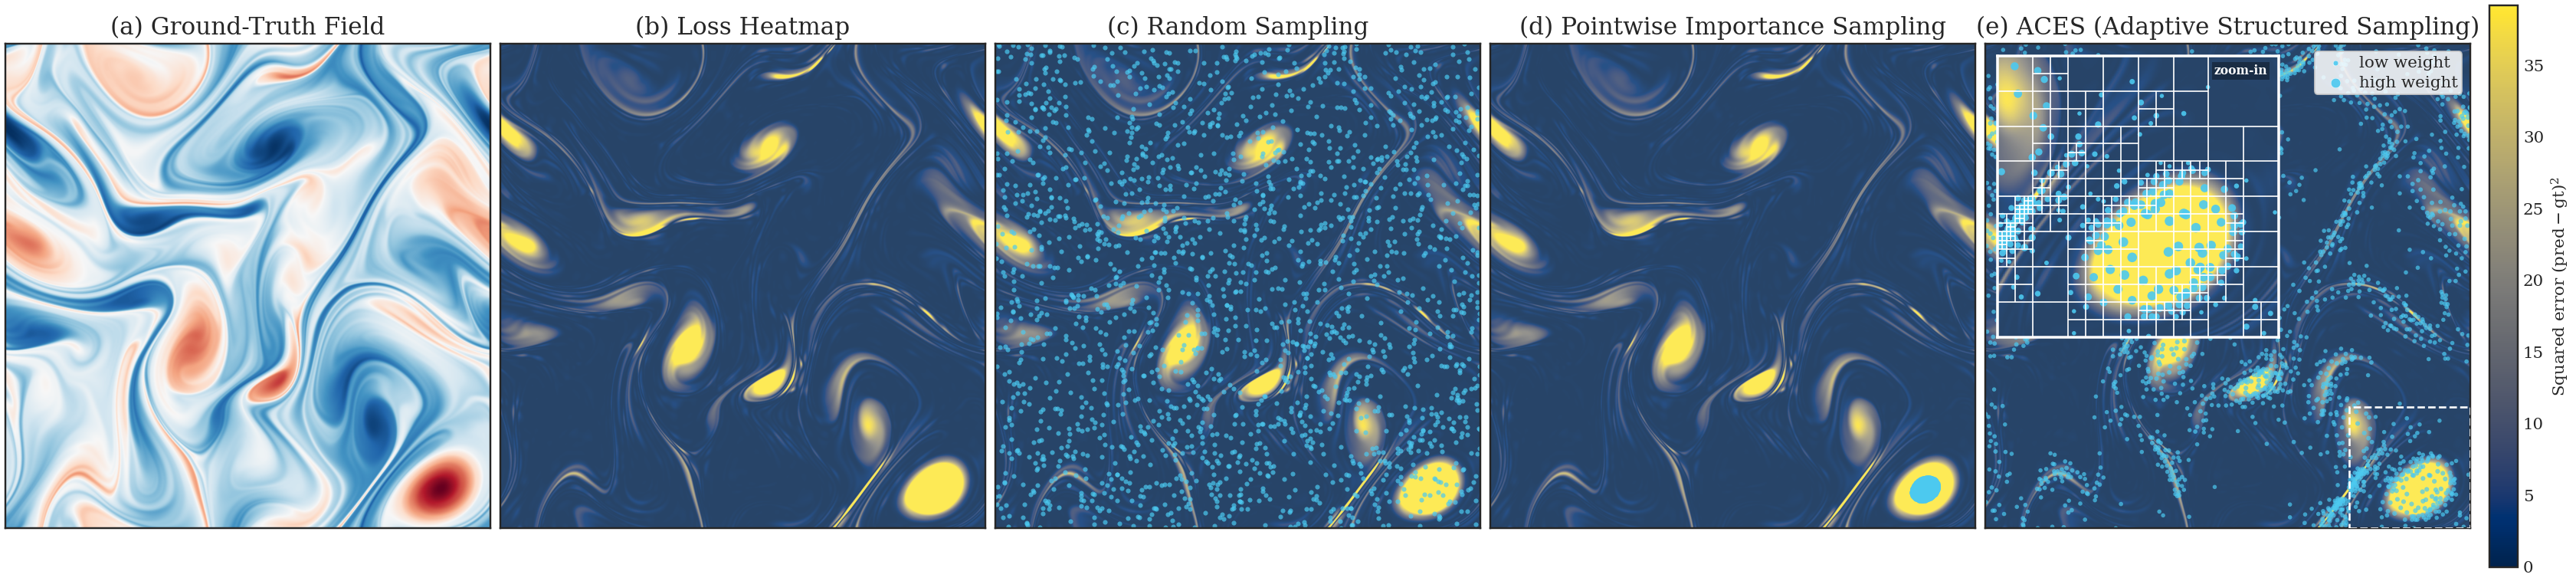

Saved paper figure to: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure/paper_iter300_loss_sampling_comparison_inset.pdf
Random sampled points: 2097
NMT sampled points: 2097
Adaptive mesh cells: 2665
Adaptive sampled points: 2097


In [12]:
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

Paper_path = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling"

plot_data_path = LATEX_EXPORT_DIR / f"paper_iter{ITER_TO_PLOT}_plot_data.npz"
assert plot_data_path.is_file(), f"Saved plot data not found: {plot_data_path}"

data_load = np.load(plot_data_path, allow_pickle=False)

gt_img = data_load["gt_img"]
pred_img = data_load["pred_img"]
loss_img = data_load["loss_img"]
bounds = data_load["bounds"]
adaptive_sample_rc = data_load["adaptive_sample_rc"]
random_sample_rc = data_load["random_sample_rc"]
nmt_sample_rc = data_load["nmt_sample_rc"]

# Backward-compatible cache load (kept for compatibility, but display size uses loss**0.25).
if "adaptive_sample_weight" in data_load.files:
    adaptive_sample_weight = data_load["adaptive_sample_weight"].astype(np.float32)
else:
    adaptive_sample_weight = np.ones(len(adaptive_sample_rc), dtype=np.float32)
    print("Warning: 'adaptive_sample_weight' not found in cache; using uniform fallback.")

loaded_iter = int(data_load["iter_to_plot"])
loaded_adaptive_name = str(data_load["adaptive_name"])

H, W = gt_img.shape

print(f"Loaded plot data from: {plot_data_path}")
print(
    f"iter={loaded_iter}, adaptive={loaded_adaptive_name}, "
    f"adaptive_samples={len(adaptive_sample_rc)}, cells={len(bounds)}"
)

# Zoom region: lower-right 256x256 under origin='lower'.
ZOOM_SIZE = 256
zoom_r0, zoom_r1 = 0, ZOOM_SIZE
zoom_c0, zoom_c1 = W - ZOOM_SIZE, W
loss_zoom = loss_img[zoom_r0:zoom_r1, zoom_c0:zoom_c1]


def _filter_pts_zoom(sample_rc, sample_w, r0, r1, c0, c1):
    """Return (x_plot, y_plot, w_plot) for points inside zoom box in local coords."""
    if len(sample_rc) == 0:
        return np.empty(0), np.empty(0), np.empty(0)
    mask = (
        (sample_rc[:, 0] >= r0)
        & (sample_rc[:, 0] < r1)
        & (sample_rc[:, 1] >= c0)
        & (sample_rc[:, 1] < c1)
    )
    pts = sample_rc[mask]
    ws = sample_w[mask]
    if len(pts) == 0:
        return np.empty(0), np.empty(0), np.empty(0)
    x = (pts[:, 1] - c0).astype(float)
    y = (pts[:, 0] - r0).astype(float)
    return x, y, ws.astype(np.float32)


def _sizes_from_weights(weights, s_min=8.0, s_max=44.0):
    """Map weights to marker sizes with robust quantile normalization."""
    if weights.size == 0:
        return np.empty(0)
    w = weights.astype(np.float32)
    lo = np.quantile(w, 0.05)
    hi = np.quantile(w, 0.95)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.full_like(w, (s_min + s_max) * 0.5)
    wn = np.clip((w - lo) / (hi - lo), 0.0, 1.0)
    return s_min + (s_max - s_min) * wn


# Display weight requested: weight = loss**0.25 at sampled points.
sample_rows = adaptive_sample_rc[:, 0].astype(np.int64)
sample_cols = adaptive_sample_rc[:, 1].astype(np.int64)
sampled_point_loss = loss_img[sample_rows, sample_cols].astype(np.float32)
vis_weight = np.power(np.clip(sampled_point_loss, 0.0, None), 0.25).astype(np.float32)

ada_zx, ada_zy, ada_zw = _filter_pts_zoom(
    adaptive_sample_rc,
    vis_weight,
    zoom_r0,
    zoom_r1,
    zoom_c0,
    zoom_c1,
)

# Build mesh segments clipped to zoom region in local coords.
# bounds format: [x0, x1, y0, y1], inclusive pixels.
zoom_segs = []
for x0, x1, y0, y1 in bounds:
    if x1 < zoom_c0 or x0 >= zoom_c1 or y1 < zoom_r0 or y0 >= zoom_r1:
        continue
    cx0 = max(float(x0), zoom_c0) - zoom_c0 - 0.5
    cx1 = min(float(x1), zoom_c1 - 1) - zoom_c0 + 0.5
    cy0 = max(float(y0), zoom_r0) - zoom_r0 - 0.5
    cy1 = min(float(y1), zoom_r1 - 1) - zoom_r0 + 0.5
    zoom_segs.extend(
        [
            [(cx0, cy0), (cx1, cy0)],
            [(cx1, cy0), (cx1, cy1)],
            [(cx1, cy1), (cx0, cy1)],
            [(cx0, cy1), (cx0, cy0)],
        ]
    )

# Style
plt.style.use("seaborn-v0_8-white")
plt.rcParams.update(
    {
        "font.family": "DejaVu Serif",
        "font.size": 11,
        "axes.titlesize": 16,
        "axes.labelsize": 11,
        "figure.dpi": 140,
        "savefig.dpi": 300,
    }
)

fig, axes = plt.subplots(1, 5, figsize=(24, 5.4), constrained_layout=True)
# Tone down loss map so panel (e) overlays stay visually dominant.
vmax_loss = np.percentile(loss_img, 98)
HEATMAP_ALPHA = 0.85

loss_norm = Normalize(vmin=0.0, vmax=vmax_loss)
# Keep colorbar colormap consistent with heatmaps.
loss_sm = ScalarMappable(norm=loss_norm, cmap="cividis")
loss_sm.set_array([])

# (a) GT
axes[0].imshow(gt_img, cmap="RdBu_r", origin="lower")
axes[0].set_title("(a) Ground-Truth Field")
axes[0].set_xticks([])
axes[0].set_yticks([])

# (b) Loss
axes[1].imshow(loss_img, cmap="cividis", origin="lower", norm=loss_norm, alpha=HEATMAP_ALPHA)
axes[1].set_title("(b) Loss Heatmap")
axes[1].set_xticks([])
axes[1].set_yticks([])

# (c) Random
axes[2].imshow(loss_img, cmap="cividis", origin="lower", norm=loss_norm, alpha=HEATMAP_ALPHA)
axes[2].set_title(f"(c) Random Sampling")
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].scatter(
    random_sample_rc[:, 1],
    random_sample_rc[:, 0],
    s=10,
    c="#4cc9f0",
    alpha=0.7,
    linewidths=0,
    zorder=2,
)

# (d) NMT
axes[3].imshow(loss_img, cmap="cividis", origin="lower", norm=loss_norm, alpha=HEATMAP_ALPHA)
axes[3].set_title(f"(d) Pointwise Importance Sampling")
axes[3].set_xticks([])
axes[3].set_yticks([])
axes[3].scatter(
    nmt_sample_rc[:, 1],
    nmt_sample_rc[:, 0],
    s=10,
    c="#4cc9f0",
    alpha=0.7,
    linewidths=0,
    zorder=2,
)

# (e) Ours: no grid on main panel, point size indicates loss**0.25.
main_sizes = _sizes_from_weights(vis_weight, s_min=8.0, s_max=10.0)
axes[4].imshow(loss_img, cmap="cividis", origin="lower", norm=loss_norm, alpha=HEATMAP_ALPHA)
axes[4].set_title(f"(e) ACES (Adaptive Structured Sampling)")
axes[4].set_xticks([])
axes[4].set_yticks([])
axes[4].scatter(
    adaptive_sample_rc[:, 1],
    adaptive_sample_rc[:, 0],
    s=main_sizes,
    c="#4cc9f0",
    edgecolors="white",
    linewidths=0,
    alpha=0.7,
    zorder=2,
)

# Draw zoom rectangle on panel (e).
zoom_rect = Rectangle(
    (zoom_c0 - 0.5, zoom_r0 - 0.5),
    ZOOM_SIZE,
    ZOOM_SIZE,
    linewidth=1.35,
    edgecolor="white",
    facecolor="none",
    linestyle="--",
    zorder=3,
)
axes[4].add_patch(zoom_rect)

# Semantic mini legend in panel (e): no numeric values.
legend_sizes = [12, 42]
legend_labels = ["low weight", "high weight"]
legend_handles = [
    axes[4].scatter([], [], s=s, c="#4cc9f0", edgecolors="white", linewidths=0.25, alpha=0.9)
    for s in legend_sizes
]
axes[4].legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    frameon=True,
    framealpha=0.86,
    fontsize=11,
    borderpad=0.25,
    handletextpad=0.45,
    labelspacing=0.3,
)

# Inset in panel (e): larger zoom + mesh + weighted points.
# width/height ~58% gives strong visual emphasis while keeping context.
axins = inset_axes(axes[4], width="58%", height="58%", loc="upper left", borderpad=0.75)
axins.imshow(loss_zoom, cmap="cividis", origin="lower", norm=loss_norm, alpha=HEATMAP_ALPHA)
axins.set_xticks([])
axins.set_yticks([])

# Strong white border around inset.
for spine in axins.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(1.8)

# Inset label.
axins.text(
    0.77,
    0.97,
    "zoom-in",
    transform=axins.transAxes,
    ha="left",
    va="top",
    color="white",
    fontsize=8,
    fontweight="bold",
    bbox=dict(facecolor="black", alpha=0.35, pad=1.6, edgecolor="none"),
)

if zoom_segs:
    axins.add_collection(
        LineCollection(zoom_segs, colors="white", linewidths=0.95, alpha=0.65, zorder=3)
    )

if len(ada_zx):
    inset_sizes = _sizes_from_weights(ada_zw, s_min=8.0, s_max=42.0)
    axins.scatter(
        ada_zx,
        ada_zy,
        s=inset_sizes,
        c="#4cc9f0",
        edgecolors="white",
        linewidths=0,
        alpha=0.9,
        zorder=2,
    )

# Shared loss colorbar for loss-based main panels only.
cbar = fig.colorbar(loss_sm, ax=[axes[1], axes[2], axes[3], axes[4]], fraction=0.024, pad=0.01)
cbar.set_label("Squared error $(\\mathrm{pred}-\\mathrm{gt})^2$", rotation=90)

# Save
out_path = f"{Paper_path}/figure/paper_iter{ITER_TO_PLOT}_loss_sampling_comparison_inset.pdf"
fig.savefig(out_path, bbox_inches="tight")
fig.savefig(str(out_path).replace(".pdf", ".png"), bbox_inches="tight")
plt.show()

print(f"Saved paper figure to: {out_path}")
print(f"Random sampled points: {len(random_sample_rc)}")
print(f"NMT sampled points: {len(nmt_sample_rc)}")
print(f"Adaptive mesh cells: {len(bounds)}")
print(f"Adaptive sampled points: {len(adaptive_sample_rc)}")

In [11]:
# Build adaptive sampler configured for loss_sqrt weight-mode testing.
# Requires: cfg, inr, graph, DEVICE already defined in previous cells.

if "cfg" not in globals() or "inr" not in globals() or "graph" not in globals():
    raise RuntimeError("Please run the checkpoint/model/graph setup cells first.")

requested_weight_mode = "loss_sqrt"
adaptive_test_overrides = {
    "type": "2d_grid_adaptive",
    "rate": 0.002,
    "adaptive_mode": "loss",
    "adaptive_iterations": 8,
    "adaptive_equal_cell_topk": True,
    "adaptive_equal_cell_topk_count_mode": "same",
    "adaptive_equal_cell_topk_weight_mode": requested_weight_mode,
    "adaptive_grid_update_interval": 1,
    "adaptive_weight_mode": "none",
}

adaptive_cfg_test = _apply_sampler_overrides(cfg, adaptive_test_overrides)

try:
    adaptive_sampler = create_inr_sampler(
        adaptive_cfg_test,
        inr,
        graph,
        current_date_str="test_",
        run_name="adaptive_loss_sqrt_mode",
        device=DEVICE,
    )
except ValueError as exc:
    print("Requested mode unavailable in currently loaded sampler:", exc)
    print("Falling back to 'area_over_count' so adaptive sampler can still be built.")
    adaptive_test_overrides["adaptive_equal_cell_topk_weight_mode"] = "area_over_count"
    adaptive_cfg_test = _apply_sampler_overrides(cfg, adaptive_test_overrides)
    adaptive_sampler = create_inr_sampler(
        adaptive_cfg_test,
        inr,
        graph,
        current_date_str="test_",
        run_name="adaptive_area_over_count_fallback",
        device=DEVICE,
    )

print("Adaptive sampler built for test.")
print("  type:", adaptive_sampler.sample_type)
print("  equal_cell_topk:", adaptive_sampler.equal_cell_topk)
print("  equal_cell_topk_weight_mode:", adaptive_sampler.equal_cell_topk_weight_mode)
print("  adaptive_mode:", adaptive_sampler.mode)

Adaptive sampler built for test.
  type: 2d_grid_adaptive
  equal_cell_topk: True
  equal_cell_topk_weight_mode: loss_sqrt
  adaptive_mode: loss


In [12]:
from unittest.mock import patch
import train_utility_sampling.SamplerWrapper as sampler_wrapper_mod


def test_adaptive_loss_sqrt_weight_mode(
    adaptive_sampler,
    graph: Data,
    inner_step: int = 0,
    atol: float = 1e-6,
    rtol: float = 1e-4,
    verbose: bool = True,
) -> dict:
    """
    Validate INRSingle2dAdaptiveSamplerWrapper when:
      - equal_cell_topk=True
      - equal_cell_topk_weight_mode='loss_sqrt'

    The function captures internal candidate samples/cell ids used by sampler.sample(),
    recomputes expected per-cell weights as sqrt(mean sampled cell loss), and checks
    they match returned sampled_graph.weight on selected top-k points.

    Returns:
        dict with pass/fail flag, max/mean abs error, and number of samples.
    """
    if not getattr(adaptive_sampler, "equal_cell_topk", False):
        raise ValueError("adaptive_sampler.equal_cell_topk must be True for this test.")
    if getattr(adaptive_sampler, "equal_cell_topk_weight_mode", None) != "loss_sqrt":
        raise ValueError(
            "adaptive_sampler.equal_cell_topk_weight_mode must be 'loss_sqrt' for this test."
        )

    captured = {}
    original_counts_fn = sampler_wrapper_mod.sample_counts_poisson
    original_var_sample_fn = sampler_wrapper_mod.sample_variable_from_2d_intervals_vcounts

    def _count_hook(values, expected_total, eps=1e-12):
        out = original_counts_fn(values, expected_total, eps=eps)
        captured["counts"] = out.detach().clone()
        captured["values"] = values.detach().clone()
        captured["expected_total"] = float(expected_total)
        return out

    def _sample_hook(bounds, counts, device="cuda"):
        samples_xy, cell_ids, ptr = original_var_sample_fn(bounds, counts, device=device)
        captured["bounds"] = bounds.detach().clone()
        captured["counts_in_sample"] = counts.detach().clone()
        captured["samples_xy"] = samples_xy.detach().clone()
        captured["cell_ids"] = cell_ids.detach().clone()
        captured["ptr"] = ptr.detach().clone()
        return samples_xy, cell_ids, ptr

    with patch.object(sampler_wrapper_mod, "sample_counts_poisson", side_effect=_count_hook), patch.object(
        sampler_wrapper_mod, "sample_variable_from_2d_intervals_vcounts", side_effect=_sample_hook
    ):
        sampled_graph = adaptive_sampler.sample(inner_step=inner_step, graph=graph, save_image=False)

    if "samples_xy" not in captured or "cell_ids" not in captured:
        raise RuntimeError("Failed to capture internal adaptive sampling tensors.")

    device = adaptive_sampler.device
    graph_on_device = graph.to(device)

    samples_xy = captured["samples_xy"].to(device)
    cell_ids = captured["cell_ids"].to(device)
    counts = captured["counts_in_sample"].to(device)
    n_cells = int(captured["bounds"].shape[0])

    x_coords = samples_xy[:, 0]
    y_coords = samples_xy[:, 1]
    sampled_idx = y_coords * adaptive_sampler.image_width + x_coords

    with torch.no_grad():
        space_emb = graph_on_device.space_emb[sampled_idx]
        feats = graph_on_device.feat[sampled_idx]
        preds = adaptive_sampler.model(space_emb)

        # Same top-k criterion as sampler.sample() in equal_cell_topk branch
        sampled_dif = torch.sum((feats - preds).abs(), dim=1)
        keep_k = min(int(graph.cor.shape[0] * adaptive_sampler.sample_rate), sampled_dif.numel())
        _, topk_local = torch.topk(sampled_dif, keep_k)

        # Expected loss_sqrt per-cell weight
        per_point_loss = (feats - preds).pow(2).sum(dim=1)
        per_cell_loss_sum = torch.zeros(n_cells, device=device, dtype=torch.float32)
        per_cell_loss_sum.index_add_(0, cell_ids, per_point_loss.to(torch.float32))

        counts_f = counts.to(torch.float32).clamp_min(1.0)
        per_cell_mean_loss = per_cell_loss_sum / counts_f
        per_cell_weight = torch.sqrt(per_cell_mean_loss.clamp_min(0.0))
        per_cell_weight = adaptive_sampler._normalize_and_clip_cell_weights(per_cell_weight)

        selected_cell_ids = cell_ids[topk_local]
        expected_weight = per_cell_weight[selected_cell_ids]

    if not hasattr(sampled_graph, "weight") or sampled_graph.weight is None:
        raise RuntimeError("sampled_graph.weight missing; expected weight tensor for loss_sqrt mode.")

    got_weight = sampled_graph.weight.to(device).to(torch.float32)
    expected_weight = expected_weight.to(torch.float32)

    abs_err = (got_weight - expected_weight).abs()
    max_abs_err = float(abs_err.max().item()) if abs_err.numel() > 0 else 0.0
    mean_abs_err = float(abs_err.mean().item()) if abs_err.numel() > 0 else 0.0
    passed = bool(torch.allclose(got_weight, expected_weight, atol=atol, rtol=rtol))

    result = {
        "pass": passed,
        "n_samples": int(got_weight.numel()),
        "max_abs_err": max_abs_err,
        "mean_abs_err": mean_abs_err,
        "atol": float(atol),
        "rtol": float(rtol),
    }

    if verbose:
        print("loss_sqrt weight-mode test:", result)

    return result

In [13]:
test_adaptive_loss_sqrt_weight_mode(adaptive_sampler, graph)

loss_sqrt weight-mode test: {'pass': True, 'n_samples': 2097, 'max_abs_err': 0.0, 'mean_abs_err': 0.0, 'atol': 1e-06, 'rtol': 0.0001}


{'pass': True,
 'n_samples': 2097,
 'max_abs_err': 0.0,
 'mean_abs_err': 0.0,
 'atol': 1e-06,
 'rtol': 0.0001}

In [14]:
# Per adaptive cell: sample 4 points, compute avg grad L2^2, and cosine to full-graph ref gradient
if "bounds" not in globals():
    raise RuntimeError("`bounds` not found. Run the adaptive sampling/plot-data cell first.")
if "graph" not in globals() or "inr" not in globals():
    raise RuntimeError("`graph` or `inr` not found. Run the checkpoint reconstruction cell first.")

SAMPLES_PER_CELL = 4

# 1) Full-graph reference gradient
inr.train()
inr.zero_grad(set_to_none=True)
pred_ref = inr(graph.space_emb)
loss_ref = (pred_ref - graph.feat).pow(2).mean()
loss_ref.backward()

params = [p for p in inr.parameters() if p.requires_grad]
ref_grad_vec = torch.cat([p.grad.detach().reshape(-1) for p in params if p.grad is not None])
ref_grad_norm = ref_grad_vec.norm().clamp_min(1e-12)
inr.zero_grad(set_to_none=True)

print(
    f"Full-graph ref gradient ||g_ref||={ref_grad_norm.item():.6f}, "
    f"dim={ref_grad_vec.numel()}, samples/cell={SAMPLES_PER_CELL}"
)

# 2) Build per-point squared error map (no grad)
inr.eval()
with torch.no_grad():
    pred_full = inr(graph.space_emb)
    per_point_loss = (pred_full - graph.feat).pow(2).reshape(-1)

coords = graph.cor.detach().cpu().long()  # (row, col)
rows = coords[:, 0]
cols = coords[:, 1]

# 3) Per-cell stats using sampled points
cell_records = []
for cell_id, (x0, x1, y0, y1) in enumerate(bounds):
    x0, x1, y0, y1 = int(x0), int(x1), int(y0), int(y1)

    # Inclusive bounds: y in [y0, y1], x in [x0, x1]
    mask = (rows >= y0) & (rows <= y1) & (cols >= x0) & (cols <= x1)
    idx_all = torch.nonzero(mask, as_tuple=False).reshape(-1).to(graph.space_emb.device)

    if idx_all.numel() == 0:
        cell_records.append({
            "cell_id": cell_id,
            "x0": x0,
            "x1": x1,
            "y0": y0,
            "y1": y1,
            "n_points_total": 0,
            "n_points_sampled": 0,
            "avg_loss": float("nan"),
            "avg_grad_l2_sq": float("nan"),
            "sampled_batch_grad_l2": float("nan"),
            "cos_sim_to_ref": float("nan"),
        })
        continue

    n_sample = min(SAMPLES_PER_CELL, int(idx_all.numel()))
    sampled_pos = torch.randperm(idx_all.numel(), device=idx_all.device)[:n_sample]
    idx = idx_all[sampled_pos]

    avg_loss = float(per_point_loss[idx].mean().item())

    # Per-point grad L2^2 on sampled points, then average within cell
    grad_l2_sq_vals = []
    for pt_idx in idx:
        inr.train()
        inr.zero_grad(set_to_none=True)

        pred_pt = inr(graph.space_emb[pt_idx : pt_idx + 1])
        feat_pt = graph.feat[pt_idx : pt_idx + 1]
        pt_loss = (pred_pt - feat_pt).pow(2).mean()
        pt_loss.backward()

        pt_grad_vec = torch.cat([p.grad.detach().reshape(-1) for p in params if p.grad is not None])
        grad_l2_sq_vals.append(float((pt_grad_vec * pt_grad_vec).sum().item()))

    avg_grad_l2_sq = float(np.mean(grad_l2_sq_vals))

     

    # Also compute sampled-batch gradient cosine similarity to reference gradient
    inr.train()
    inr.zero_grad(set_to_none=True)
    pred_cell = inr(graph.space_emb[idx])
    feat_cell = graph.feat[idx]
    cell_loss = (pred_cell - feat_cell).pow(2).mean()
    cell_loss.backward()

    cell_grad_vec = torch.cat([p.grad.detach().reshape(-1) for p in params if p.grad is not None])
    inr.zero_grad(set_to_none=True)

    sampled_batch_grad_l2 = float(cell_grad_vec.norm().item())
    cell_grad_norm = cell_grad_vec.norm().clamp_min(1e-12)
    cos_sim = float(torch.dot(cell_grad_vec, ref_grad_vec) / (cell_grad_norm * ref_grad_norm))

    weight_coeff  =float(torch.dot(cell_grad_vec, ref_grad_vec) / avg_grad_l2_sq) /int(idx_all.numel())

    cell_records.append({
        "cell_id": cell_id,
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "n_points_total": int(idx_all.numel()),
        "n_points_sampled": int(n_sample),
        "avg_loss": avg_loss,
        "avg_grad_l2_sq": avg_grad_l2_sq,
        "sampled_batch_grad_l2": sampled_batch_grad_l2,
        "cos_sim_to_ref": cos_sim,
        "weight_coeff": weight_coeff,
    })

inr.eval()
adaptive_cell_stats_df = pd.DataFrame(cell_records).sort_values("cell_id").reset_index(drop=True)

print(f"\nComputed stats for {len(adaptive_cell_stats_df)} adaptive cells.")
print(
    adaptive_cell_stats_df[["avg_loss", "avg_grad_l2_sq", "sampled_batch_grad_l2", "cos_sim_to_ref"]]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .to_string()
)

print("\nTop-10 cells by avg_grad_l2_sq:")
print(adaptive_cell_stats_df.sort_values("avg_grad_l2_sq", ascending=False).head(10).to_string(index=False))


Full-graph ref gradient ||g_ref||=20.613811, dim=97341, samples/cell=4

Computed stats for 2665 adaptive cells.
          avg_loss  avg_grad_l2_sq  sampled_batch_grad_l2  cos_sim_to_ref
count  2665.000000    2.665000e+03            2665.000000     2665.000000
mean      2.020500    2.077251e+07            1399.307294        0.062224
std       6.894885    1.195841e+08            3756.750658        0.111651
min       0.000160    4.961215e+02               7.307260       -0.223362
25%       0.042532    9.466522e+04             171.764679        0.005829
50%       0.151369    4.005777e+05             384.383453        0.027338
75%       0.634046    2.147033e+06            1001.008911        0.073998
max      60.982384    1.598705e+09           38379.457031        0.570756

Top-10 cells by avg_grad_l2_sq:
 cell_id  x0  x1  y0  y1  n_points_total  n_points_sampled  avg_loss  avg_grad_l2_sq  sampled_batch_grad_l2  cos_sim_to_ref  weight_coeff
     328 778 779  90  91               4           

/tmp/ipykernel_2148249/804947234.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(


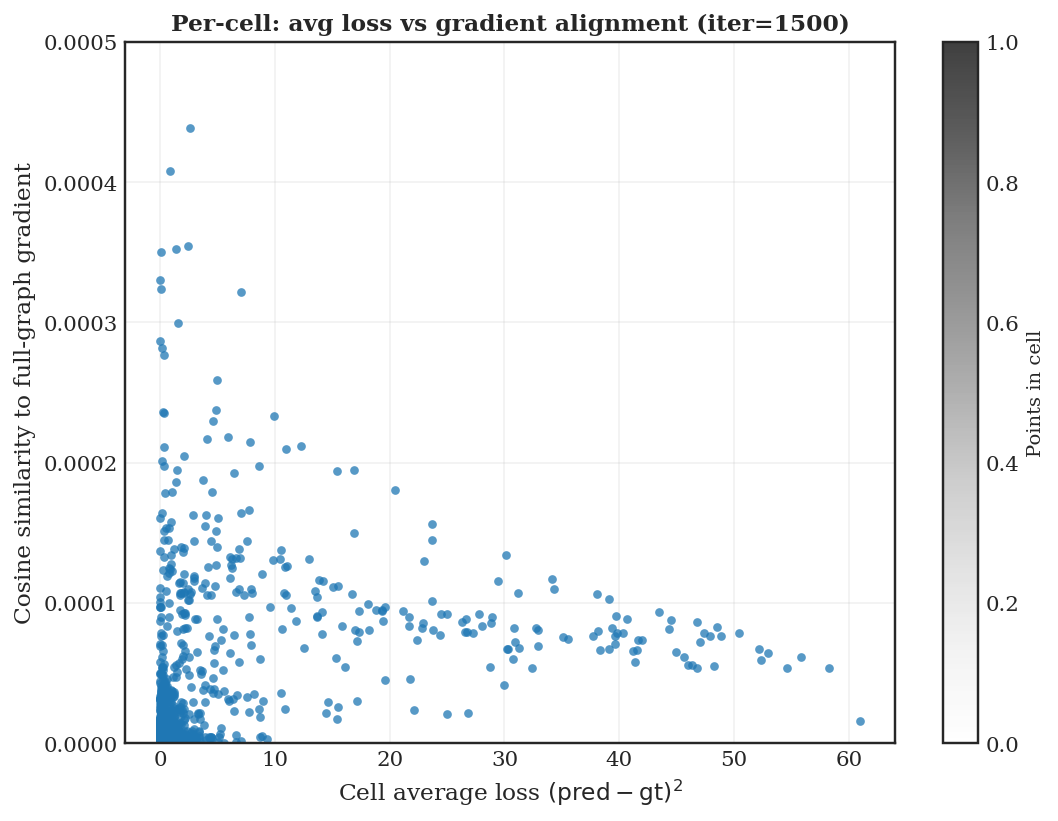

Saved → /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/paper_data/cell_loss_vs_cos_sim_iter1500.png


In [15]:

# Scatter: avg_loss (x) vs cos_sim_to_ref (y), coloured by cell size (n_points)
df = adaptive_cell_stats_df.dropna(subset=["avg_loss", "cos_sim_to_ref"])

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    df["avg_loss"],
    df["weight_coeff"],
    cmap="viridis",
    s=20,
    alpha=0.75,
    linewidths=0,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Points in cell", fontsize=10)

ax.set_xlabel("Cell average loss $(\\mathrm{pred}-\\mathrm{gt})^2$", fontsize=12)
ax.set_ylabel("Cosine similarity to full-graph gradient", fontsize=12)
ax.set_title(
    f"Per-cell: avg loss vs gradient alignment (iter={ITER_TO_PLOT})",
    fontsize=12, fontweight="bold",
)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.0005)

plt.tight_layout()
out = LATEX_EXPORT_DIR / f"cell_loss_vs_cos_sim_iter{ITER_TO_PLOT}.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved → {out}")


## 5. Compute Gradient Statistics

For each (sampler, step) pair compute:
- Per-repeat gradient L2 norms
- Mean and std of norms across repeats
- Gradient variance (mean element-wise variance across repeats)
- Average pairwise cosine similarity across repeats
- Orthogonal error relative to the full-graph reference gradient

In [16]:
def avg_pairwise_cosine(grads: list[torch.Tensor]) -> float:
    """Mean pairwise cosine similarity across a list of gradient vectors."""
    if len(grads) < 2:
        return float("nan")
    g = torch.stack(grads, dim=0).float()
    norms = g.norm(dim=1, keepdim=True).clamp_min(1e-12)
    g_norm = g / norms
    cos_mat = g_norm @ g_norm.t()
    idx = torch.triu_indices(len(grads), len(grads), offset=1)
    return float(cos_mat[idx[0], idx[1]].mean().item())


def grad_variance(grads: list[torch.Tensor]) -> float:
    """Mean element-wise variance across repeated gradient vectors."""
    if len(grads) < 2:
        return float("nan")
    g = torch.stack(grads, dim=0).float()
    return float(g.var(dim=0, unbiased=False).mean().item())


def cosine_similarity_to_ref(grads: list[torch.Tensor], ref_grad: torch.Tensor) -> tuple[float, float]:
    """Return mean/std cosine similarity between repeated grads and ref_grad."""
    if not grads or ref_grad.numel() == 0:
        return float("nan"), float("nan")

    ref = ref_grad.float()
    ref_norm = ref.norm().clamp_min(1e-12)

    cos_vals = []
    for g in grads:
        g = g.float()
        g_norm = g.norm().clamp_min(1e-12)
        cos_vals.append(float(torch.dot(g, ref) / (g_norm * ref_norm)))

    cos_arr = np.asarray(cos_vals, dtype=np.float64)
    return float(cos_arr.mean()), float(cos_arr.std())


def orthogonal_error(sample_grads: list[torch.Tensor], ref_grad: torch.Tensor) -> tuple[float, float]:
    """Squared norm of the component of each sample gradient orthogonal to ref_grad."""
    if not sample_grads or ref_grad.numel() == 0:
        return float("nan"), float("nan")
    g = torch.stack(sample_grads, dim=0).float()
    ref = ref_grad.float()
    ref_norm_sq = ref.dot(ref)
    if ref_norm_sq.item() <= 1e-20:
        dist_sq = (g * g).sum(dim=1)
    else:
        proj_coeff = (g @ ref) / ref_norm_sq
        proj = proj_coeff.unsqueeze(1) * ref.unsqueeze(0)
        residual = g - proj
        dist_sq = (residual * residual).sum(dim=1)
    return float(dist_sq.mean().item()), float(dist_sq.std(unbiased=False).item())


# Pre-compute per-step reference (full-graph) gradients from the original checkpoint
print("Computing reference (full-graph) gradients ...")
ref_grads: dict[int, torch.Tensor] = {}
for step, ckpt_path in checkpoint_steps:
    ckpt = _load_checkpoint(ckpt_path)
    cfg = ckpt["cfg"]
    input_dim = int(ckpt.get("input_dim", 2))
    output_dim = int(ckpt.get("output_dim", 1))
    dev = torch.device(DEVICE)

    inr = create_inr_instance(cfg, input_dim, output_dim, dev)
    inr.load_state_dict(ckpt["inr"])
    inr.to(dev).train()
    inr.zero_grad(set_to_none=True)

    graph = _build_graph(ckpt, dev)
    pred = inr(graph.space_emb)
    loss = _weighted_mse(pred, graph.feat, weight=None)
    loss.backward()
    ref_grads[step] = _flatten_gradients(inr).cpu()

print(f"  Reference gradients computed for {len(ref_grads)} steps.")

# Build statistics DataFrame
rows = []
for sampler_name, step_grads in results.items():
    for step, grads in step_grads.items():
        if not grads:
            continue

        norms = [g.norm().item() for g in grads]
        cos_ref_mean, cos_ref_std = cosine_similarity_to_ref(grads, ref_grads[step])
        ortho_mean, ortho_std = orthogonal_error(grads, ref_grads[step])

        rows.append({
            "sampler": sampler_name,
            "step": step,
            "norm_mean": float(np.mean(norms)),
            "norm_std": float(np.std(norms)),
            "grad_variance": grad_variance(grads),
            "avg_pairwise_cosine": avg_pairwise_cosine(grads),
            "cosine_to_ref_mean": cos_ref_mean,
            "cosine_to_ref_std": cos_ref_std,
            "ortho_error_mean": ortho_mean,
            "ortho_error_std": ortho_std,
            # mean gradient vector (stored for later similarity analysis)
            "_mean_grad": torch.stack(grads, dim=0).mean(dim=0),
        })

stats_df = pd.DataFrame(rows)
print(stats_df.drop(columns=["_mean_grad"]).to_string(index=False))

Computing reference (full-graph) gradients ...
  Reference gradients computed for 31 steps.
                sampler  step   norm_mean  norm_std  grad_variance  avg_pairwise_cosine  cosine_to_ref_mean  cosine_to_ref_std  ortho_error_mean  ortho_error_std
 original (random 2e-3)     0   14.810161  0.608873       0.000163             0.911175            0.954040           0.007325      1.952007e+01         1.867032
 original (random 2e-3)   100   55.979305  1.721582       0.003383             0.869648            0.931754           0.004500      4.127995e+02        28.354931
 original (random 2e-3)   200   47.853991  1.349154       0.006486             0.656503            0.812376           0.014673      7.802016e+02        86.584122
 original (random 2e-3)   300   55.990367  5.165690       0.013259             0.496138            0.720775           0.036513      1.524070e+03       351.609070
 original (random 2e-3)   400   46.736201  4.439530       0.011182             0.388324           

In [17]:
def _mean_grad(sampler_name: str, step: int) -> torch.Tensor:
    """Helper to extract the mean gradient vector for a given sampler and step."""
    g_list = results.get(sampler_name, {}).get(step, [])
    g_tensor = torch.stack(g_list, dim=0) if g_list else torch.tensor([])
    return g_tensor.mean(dim=0) if g_tensor.numel() > 0 else torch.tensor([])

def _square_grad(sampler_name: str, step: int) -> torch.Tensor:
    """Helper to extract the element-wise variance of gradients for a given sampler and step."""
    g_list = results.get(sampler_name, {}).get(step, [])
    g_tensor = torch.stack(g_list, dim=0) if g_list else torch.tensor([])
    
    return torch.sum(g_tensor**2, dim=1).mean() if g_tensor.numel() > 0 else torch.tensor([])

def _ref_grad(step: int) -> torch.Tensor:
    """Helper to get the reference full-graph gradient for a given step."""
    return ref_grads.get(step, torch.tensor([]))

_square_grad('random 4e-3', 1000)

tensor(889.1824)

In [18]:
gradient_alignment_metric('random 4e-3', 1000)

NameError: name 'gradient_alignment_metric' is not defined

In [19]:
_square_grad('random 4e-3', 1000)

tensor(889.1824)

In [20]:
(_mean_grad('random 4e-3', 1000)**2).sum()

tensor(609.2403)

## 11. Gradient Alignment Metric Over Training Steps

Compute the metric: `(mean_grad · ref_grad)² / sum(mean_grad²)` for each sampler and step.
This measures how well the sampled-gradient direction aligns with the full-graph reference gradient,
normalized by the magnitude of the sampled gradient.


In [23]:
results.keys()

dict_keys(['original (random 2e-3)', 'random 4e-3', 'NMT 2e-3', '2d_grid_linear', '2d_grid_adaptive (loss)'])

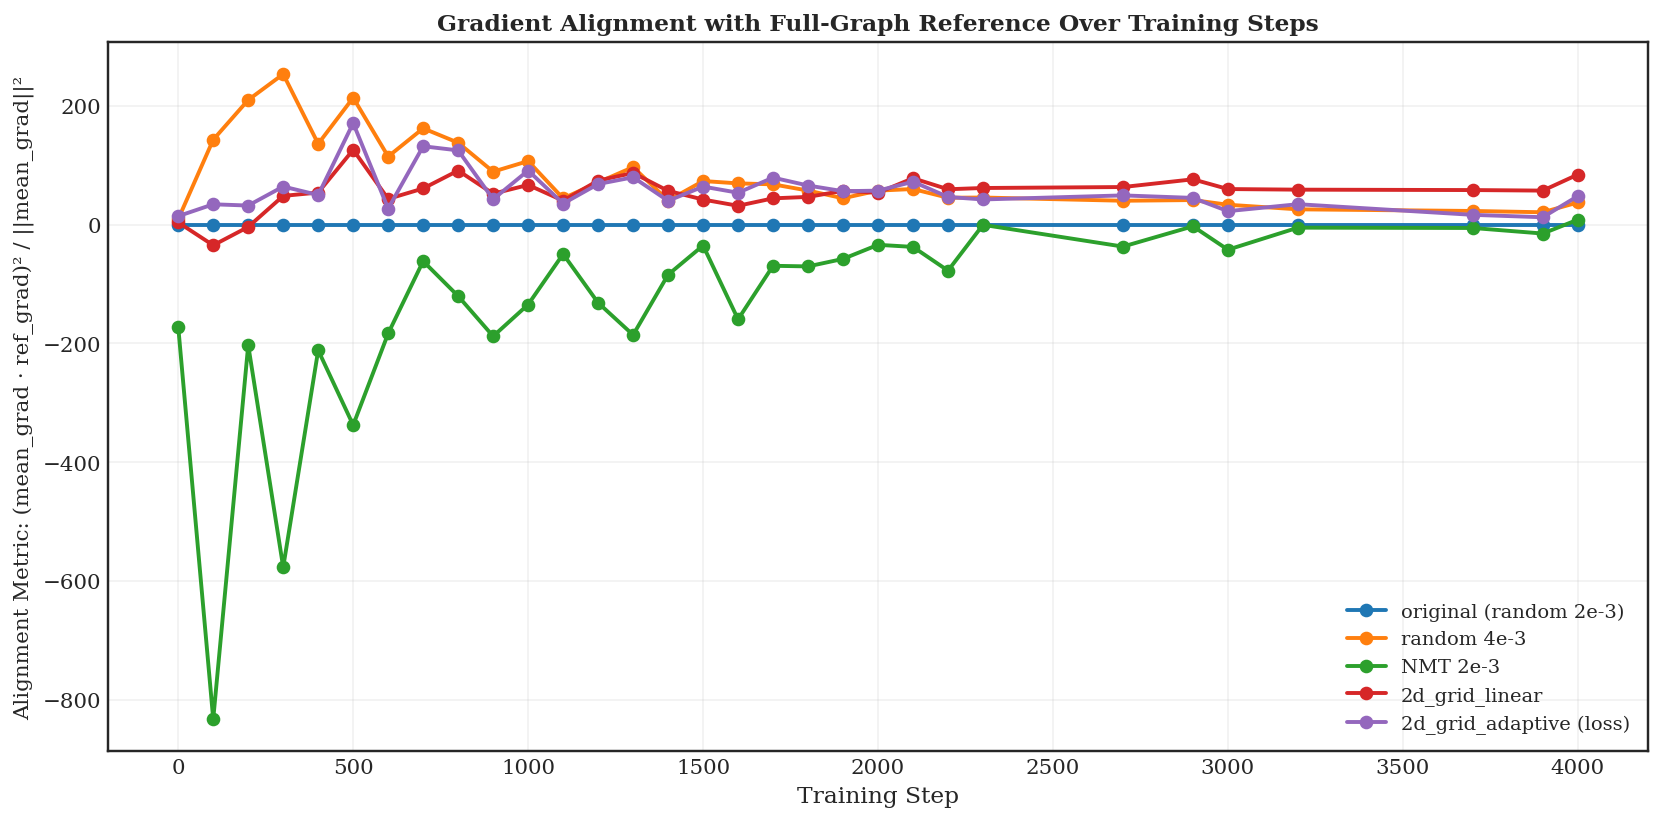


=== Gradient Alignment Metric Summary ===



KeyError: '2d_grid_adaptive (loss_sqrt_std)'

In [27]:
PALETTE = sns.color_palette("tab10", n_colors=len(results.keys()))
SAMPLER_COLORS = {name: PALETTE[i] for i, name in enumerate(results.keys())}
def gradient_alignment_metric(sampler_name: str, step: int) -> float:
    """
    Compute gradient alignment: (mean_grad · ref_grad)² / ||mean_grad||²
    
    Higher values indicate better alignment with the full-graph reference gradient.
    """
    mean_g = _mean_grad(sampler_name, step)
    ref_g = _ref_grad(step)
    
    if mean_g.numel() == 0 or ref_g.numel() == 0:
        return float("nan")
    
    dot_product = float(torch.dot(mean_g, ref_g))
    norm_sq = float(torch.sum(mean_g ** 2))
    norm_sq = _square_grad(sampler_name, step)
    
    if norm_sq <= 1e-20:
        return float("nan")
    
    return (dot_product ** 2) / norm_sq


# Compute alignment metric for all (sampler, step) pairs
alignment_data: dict[str, tuple[list[int], list[float]]] = {}

for sampler_name in results.keys():
    steps_list = []
    metrics_list = []
    
    for step in sorted(results[sampler_name].keys()):
        metric = gradient_alignment_metric(sampler_name, step)
        steps_list.append(step)
        metrics_list.append(metric)
    
    alignment_data[sampler_name] = (steps_list, metrics_list)

# Plot alignment metric over training steps
fig, ax = plt.subplots(figsize=(12, 6))

standard = alignment_data['original (random 2e-3)'][1]

for sampler_name in results.keys():
    steps, metrics = alignment_data[sampler_name]
    # normalize with standard
    metrics = [m - s for m, s in zip(metrics, standard)]
    ax.plot(
        steps, metrics,
        marker="o", markersize=6,
        label=sampler_name,
        color=SAMPLER_COLORS[sampler_name],
        linewidth=2,
    )

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Alignment Metric: (mean_grad · ref_grad)² / ||mean_grad||²", fontsize=11)
ax.set_title("Gradient Alignment with Full-Graph Reference Over Training Steps", fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR.parent / "sampler_gradient_alignment_metric.png", dpi=150)
plt.show()

# Print summary stats
print("\n=== Gradient Alignment Metric Summary ===\n")
alignment_summary = []
for sampler_name in SAMPLER_CONFIGS:
    steps, metrics = alignment_data[sampler_name]
    metrics_arr = np.array(metrics)
    valid_metrics = metrics_arr[~np.isnan(metrics_arr)]
    
    if len(valid_metrics) > 0:
        alignment_summary.append({
            "sampler": sampler_name,
            "mean": float(valid_metrics.mean()),
            "std": float(valid_metrics.std()),
            "min": float(valid_metrics.min()),
            "max": float(valid_metrics.max()),
        })

alignment_df = pd.DataFrame(alignment_summary)
pd.set_option("display.float_format", "{:.6f}".format)
print(alignment_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for sampler_name in SAMPLER_CONFIGS:
    steps, metrics = alignment_data[sampler_name]
    # normalize with standard
    metrics = [m - s for m, s in zip(metrics, standard)]
    ax.plot(
        steps, metrics,
        marker="o", markersize=6,
        label=sampler_name,
        color=SAMPLER_COLORS[sampler_name],
        linewidth=2,
    )

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Alignment Metric: (mean_grad · ref_grad)² / ||mean_grad||²", fontsize=11)
ax.set_title("Gradient Alignment with Full-Graph Reference Over Training Steps", fontsize=12, fontweight="bold")
# set y axis to log
ax.set_yscale("log")
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
alignment_data['original (random 2e-3)'][1] - alignment_data['2d_grid_adaptive (loss)'][1]

In [ ]:
(g*ges).sum() / (g.norm() * ges.norm())